# Imports

In [1]:
import os
import zipfile
from pathlib import Path
from typing import Callable, Tuple

import gdown

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchshow as ts
import torch.optim as optim
import torchmetrics
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import VGG16_Weights
from pytorch_lightning.callbacks import ModelCheckpoint
import pytorch_lightning as pl

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from tqdm.notebook import tqdm
from IPython.display import Image, display
from PIL import Image

# Variable declaration

In [2]:
url__data_origin = "https://drive.google.com/drive/folders/10KMK0rNB43V2g30NcA1RYipL535DuZ-h"
fil__raw_dataset_trainvalidation = "train_val.zip"
fil__raw_dataset_test = "TEST.zip"

dir__running = os.path.join(os.getcwd(), "..")
dir__raw_data = os.path.join(dir__running, "data", "raw")

path__raw_dataset_trainvalidation = os.path.join(dir__raw_data, fil__raw_dataset_trainvalidation)
path__raw_dataset_test = os.path.join(dir__raw_data, fil__raw_dataset_test)

dir__dataset = os.path.join(dir__running, "data", "dataset")
dir__dataset_trainvalidation = os.path.join(dir__dataset, "train-validation")
dir__dataset_test = os.path.join(dir__dataset, "test")

dir__dataset_trainvalidation_images = os.path.join(dir__dataset_trainvalidation, "images")
dir__dataset_trainvalidation_labels = os.path.join(dir__dataset_trainvalidation, "labels")

dir__dataset_test_images = os.path.join(dir__dataset_test, "images")
dir__dataset_test_labels = os.path.join(dir__dataset_test, "labels")

# Data acquisition

In [3]:
def ensure_dir(dir):
    if not os.path.exists(dir):
        os.makedirs(dir)


def download_from_google_drive(url, file_path):
    print(f"Downloading {url} to {file_path}...")
    gdown.download_folder(url__data_origin, quiet = False, output = file_path)
    print("Download completed.")


def unzip_file(zip_path, target_dir):
    ensure_dir(target_dir)
    if not os.path.exists(target_dir) or len(os.listdir(target_dir)) == 0:
        print(f"extracting {zip_path} to {target_dir}...")
        file_name = os.path.basename(zip_path)
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(target_dir)
        for file in os.listdir(os.path.join(target_dir, file_name.split(".")[0])):
            os.rename(
                os.path.join(target_dir, file_name.split(".")[0], file),
                os.path.join(target_dir, file),
            )
        os.rmdir(os.path.join(target_dir, file_name.split(".")[0]))
        print(f"{zip_path} successfully extracted to {target_dir}.")
    else:
        print(f"{zip_path} already extracted to {target_dir}.")

In [4]:
ensure_dir(dir__raw_data)

if not os.path.isfile(path__raw_dataset_trainvalidation) or not os.path.isfile(path__raw_dataset_test):
    download_from_google_drive(url__data_origin, dir__raw_data)
else:
    print("Raw datasets already downloaded.")

if not os.path.isfile(path__raw_dataset_trainvalidation) or not os.path.isfile(path__raw_dataset_test):
    raise FileNotFoundError("Raw datasets not found.")

unzip_file(path__raw_dataset_trainvalidation, dir__dataset_trainvalidation)
unzip_file(path__raw_dataset_test, dir__dataset_test)

Raw datasets already downloaded.
c:\Users\Seya.Schmassmann\Code\studium\bverI\bverI-miniproject\src\..\data\raw\train_val.zip already extracted to c:\Users\Seya.Schmassmann\Code\studium\bverI\bverI-miniproject\src\..\data\dataset\train-validation.
c:\Users\Seya.Schmassmann\Code\studium\bverI\bverI-miniproject\src\..\data\raw\TEST.zip already extracted to c:\Users\Seya.Schmassmann\Code\studium\bverI\bverI-miniproject\src\..\data\dataset\test.


In [5]:
trainvalidation_tuples_paths = [
    (
        os.path.join(dir__dataset_trainvalidation_images, file_name),
        os.path.join(dir__dataset_trainvalidation_labels, file_name.split(".")[0] + ".bmp"),
    )
    for file_name in os.listdir(dir__dataset_trainvalidation_images)
]
test_tuples_paths = [
    (
        os.path.join(dir__dataset_test_images, file_name),
        os.path.join(dir__dataset_test_labels, file_name.split(".")[0] + ".bmp"),
    )
    for file_name in os.listdir(dir__dataset_test_images)
]

# Data analysis

## Categories

| Color                                 | Description               |
| ------------------------------------- | ------------------------- |
| <span style="color:#000000;">⬤</span> | Background waterbody      |
| <span style="color:#0000FF;">⬤</span> | Human divers              |
| <span style="color:#00FF00;">⬤</span> | Plants/sea-grass          |
| <span style="color:#00FFFF;">⬤</span> | Wrecks/ruins              |
| <span style="color:#FF0000;">⬤</span> | Robots/instruments        |
| <span style="color:#FF00FF;">⬤</span> | Reefs and invertebrates   |
| <span style="color:#FFFF00;">⬤</span> | Fish and vertebrates      |
| <span style="color:#FFFFFF;">⬤</span> | Sand/sea-floor (& rocks)  |


Train-validation dataset contains 1525 images and labels.
Test dataset contains 110 images and labels.

Image dimensions:
  - (480, 640, 3): 1329
  - (720, 1280, 3): 57
  - (448, 480, 3): 16
  - (720, 1152, 3): 8
  - (1080, 1906, 3): 17
  - (360, 640, 3): 17
  - (480, 584, 3): 5
  - (540, 960, 3): 130
  - (600, 800, 3): 13
  - (960, 1280, 3): 1
  - (416, 416, 3): 5
  - (375, 590, 3): 31
  - (435, 910, 3): 6


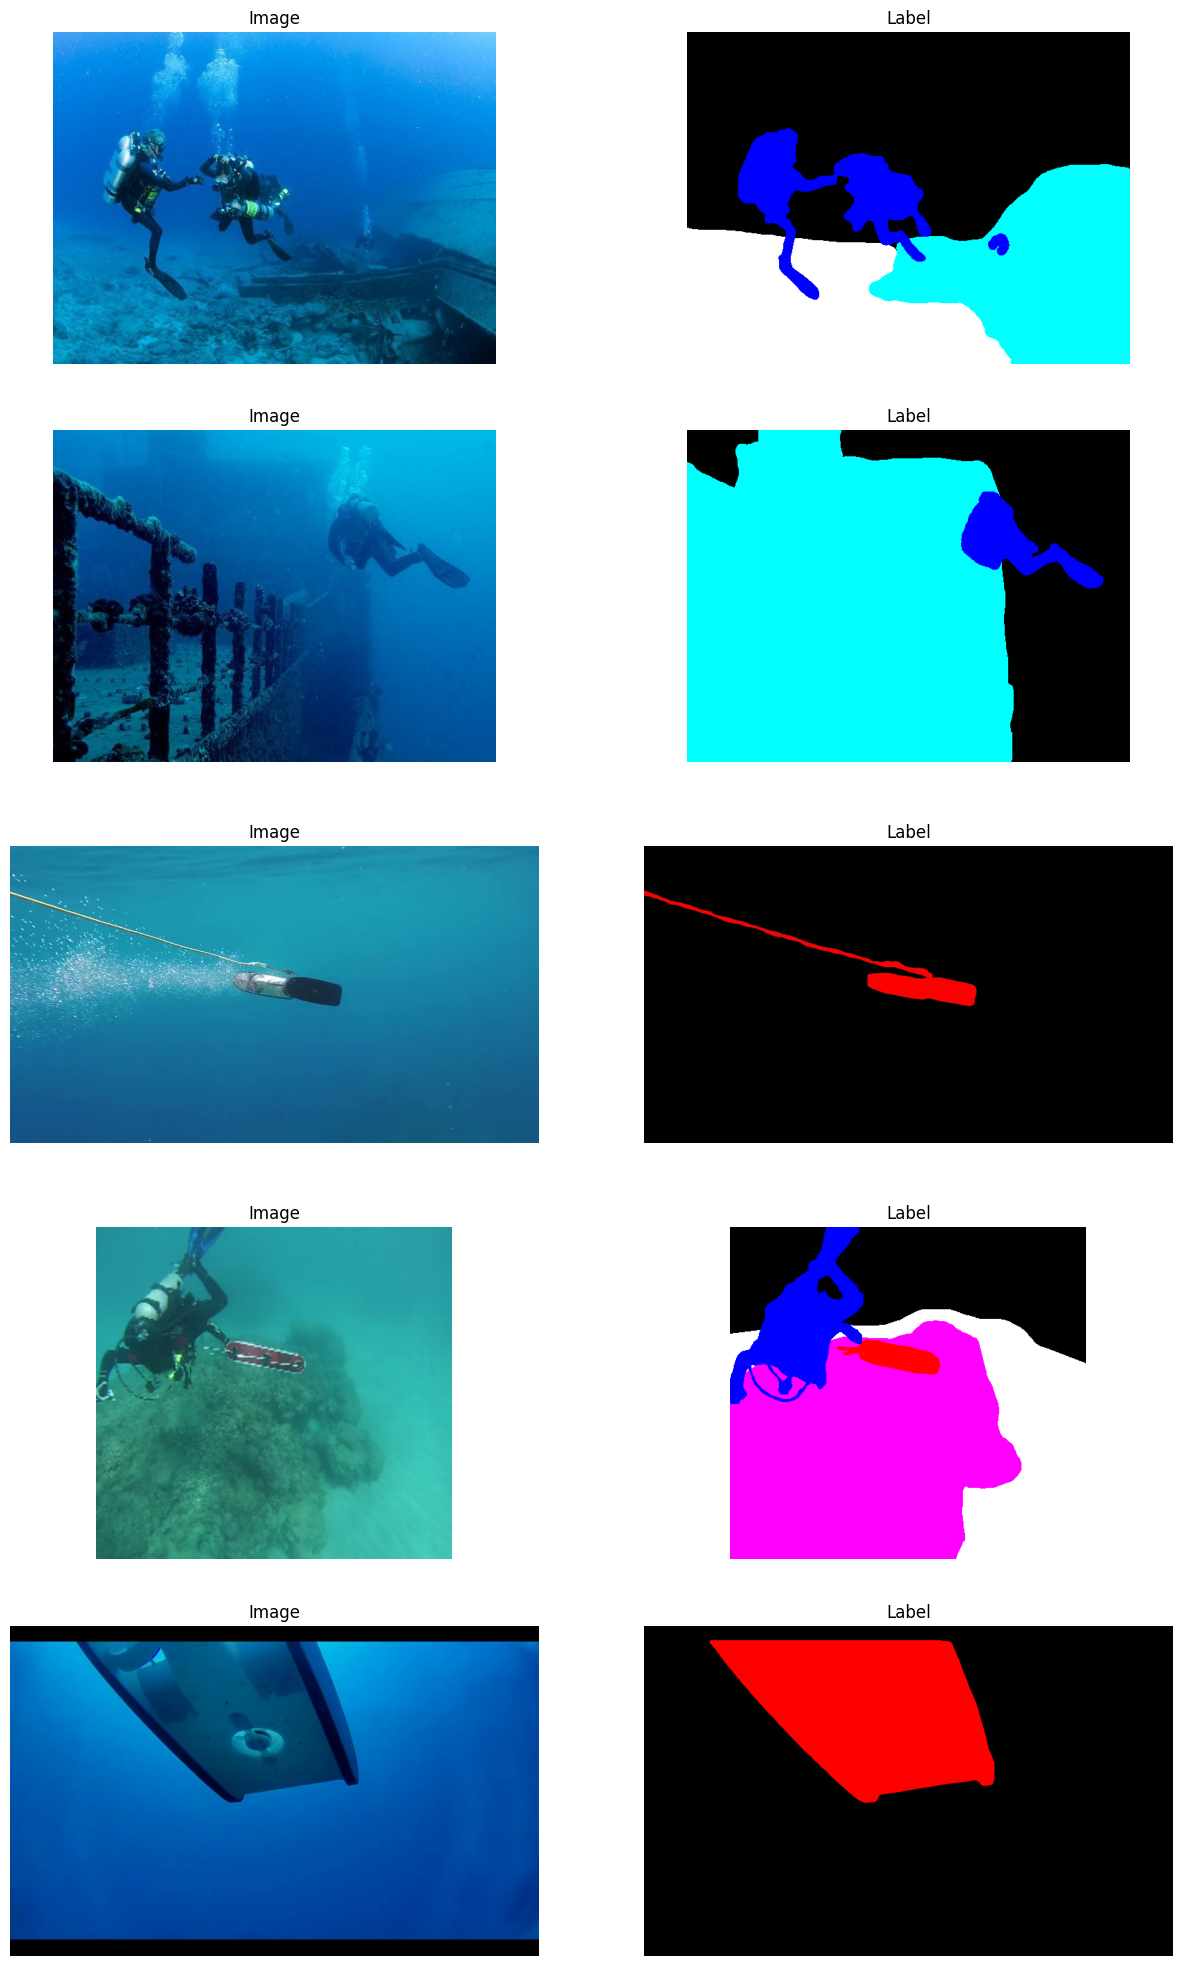

In [6]:
print(f"Train-validation dataset contains {len(trainvalidation_tuples_paths)} images and labels.")
print(f"Test dataset contains {len(test_tuples_paths)} images and labels.")

image_dims = {}
for image_path, label_path in trainvalidation_tuples_paths + test_tuples_paths:
    image = plt.imread(image_path)

    count = image_dims[image.shape] if image.shape in image_dims else 0
    image_dims[image.shape] = count + 1

print("\nImage dimensions:")
for dim, count in image_dims.items():
    print(f"  - {dim}: {count}")

fig, ax = plt.subplots(5, 2, figsize = (15, 25))

for i in range(5):
    _ = ax[i][0].axis("off")
    _ = ax[i][1].axis("off")

    _ = ax[i][0].imshow(plt.imread(trainvalidation_tuples_paths[i][0]))
    _ = ax[i][0].set_title("Image")

    _ = ax[i][1].imshow(plt.imread(trainvalidation_tuples_paths[i][1]))
    _ = ax[i][1].set_title("Label")

plt.show()

# Data preparation

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


## Dataset

In [8]:
class SuimDataset(Dataset):
    def __init__(
        self,
        data_tuples_paths,
        color_mapping: dict,
        transform_images: Callable,
        transform_labels: Callable,
        verbose: bool = False,
    ):
        """
        Initializes the dataset.

        Args:
            data_tuples_paths (Path): Path to the dataset directory.
            color_mapping (dict): Mapping of RGB colors to class indices.
            transform_images (callable): Transformation function for images.
            transform_labels (callable): Transformation function for labels.
        """
        self.data_tuples_paths = data_tuples_paths
        self.color_mapping = color_mapping
        self.num_classes = max(color_mapping.values()) + 1
        self.transform_images = transform_images
        self.transform_labels = transform_labels
        self.verbose = verbose

    def __len__(self) -> int:
        """
        Returns the length of the dataset.
        """
        return len(self.data_tuples_paths)

    def __getitem__(self, idx):
        """
        Retrieves the image and corresponding label masks for a given index.

        Args:
            idx (int): The index of the item to retrieve.

        Returns:
            tuple: A tuple containing:
                - image (torch.Tensor | Image.Image): The transformed image or original image.
                - label_masks (torch.Tensor): A binary mask tensor of shape (K, H, W) where K is the number of classes.
                  Each channel represents the binary mask for a specific class.
                - labels_tensor (torch.Tensor): A segmentation map tensor of shape (1, H, W) indicating class indices
                  for each pixel.
        """
        image_path, label_path = self.data_tuples_paths[idx]

        image = Image.open(image_path).convert("RGB")
        image_tensor = self.transform_images(image)

        label = Image.open(label_path).convert("RGB")
        label = self.transform_labels(label)

        label_categorical = np.zeros((label.height, label.width), dtype = np.uint8)
        for color, cat in self.color_mapping.items():
            mask = np.all(np.array(label) == np.array(color), axis = -1)
            label_categorical[mask] = cat

        if self.verbose:
            print(f"Image shape: {image_tensor.shape}, type: {type(image_tensor)}, dtype: {image_tensor.dtype}")
            print(f"Label shape: {label.size}, type: {type(label)}")

            fig, ax = plt.subplots(2, 2, figsize = (15, 10))

            ax[0][0].imshow(image)
            ax[0][0].axis("off")
            ax[0][0].set_title("Image")

            ax[0][1].imshow(label)
            ax[0][1].axis("off")
            ax[0][1].set_title("Label")

            ax[1][0].imshow(label_categorical)
            ax[1][0].axis("off")
            ax[1][0].set_title("Label (categorical)")

            ax[1][1].remove()

            plt.colorbar(ax[1][0].imshow(label_categorical), ax = ax[1][0])
            plt.show()

        # transform from (H, W) to (1, H, W)
        label_categorical = np.expand_dims(label_categorical, axis = 0)
        labels_tensor = torch.from_numpy(label_categorical).long()
        
        # transform from (1, H, W) to (K, H, W)
        label_masks = F.one_hot(labels_tensor.squeeze(0), num_classes = self.num_classes).permute(2, 0, 1)

        if self.verbose:
            print(f"Label masks shape: {label_masks.shape}, type: {type(label_masks)}, dtype: {label_masks.dtype}, min: {label_masks.min()}, max: {label_masks.max()}")
            print(f"Labels tensor shape: {labels_tensor.shape}, type: {type(labels_tensor)}, dtype: {labels_tensor.dtype}, min: {labels_tensor.min()}, max: {labels_tensor.max()}")


        return image_tensor, label_masks, labels_tensor

In [9]:
colors_to_8cats = {
    (0, 0, 0): 0,        # #000000 --> [BW] Background waterbody
    (0, 0, 255): 1,      # #0000FF --> [HD] Human divers
    (0, 255, 0): 2,      # #00FF00 --> [PF] Plants/sea-grass
    (0, 255, 255): 3,    # #00FFFF --> [WR] Wrecks/ruins
    (255, 0, 0): 4,      # #FF0000 --> [RO] Robots/instruments
    (255, 0, 255): 5,    # #FF00FF --> [RI] Reefs and invertebrates
    (255, 255, 0): 6,    # #FFFF00 --> [FV] Fish and vertebrates
    (255, 255, 255): 7,  # #FFFFFF --> [SR] Sand/sea-floor (& rocks)
}
colors_to_5cats = {
    (0, 0, 0): 0,        # #000000 --> [BW] Background waterbody
    (0, 0, 255): 1,      # #0000FF --> [HD] Human divers
    (0, 255, 0): 0,      # #00FF00 --> [PF] Plants/sea-grass
    (0, 255, 255): 2,    # #00FFFF --> [WR] Wrecks/ruins
    (255, 0, 0): 3,      # #FF0000 --> [RO] Robots/instruments
    (255, 0, 255): 4,    # #FF00FF --> [RI] Reefs and invertebrates
    (255, 255, 0): 5,    # #FFFF00 --> [FV] Fish and vertebrates
    (255, 255, 255): 0,  # #FFFFFF --> [SR] Sand/sea-floor (& rocks)
}

### Tests

Image shape: torch.Size([3, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.float32
Label shape: (320, 256), type: <class 'PIL.Image.Image'>


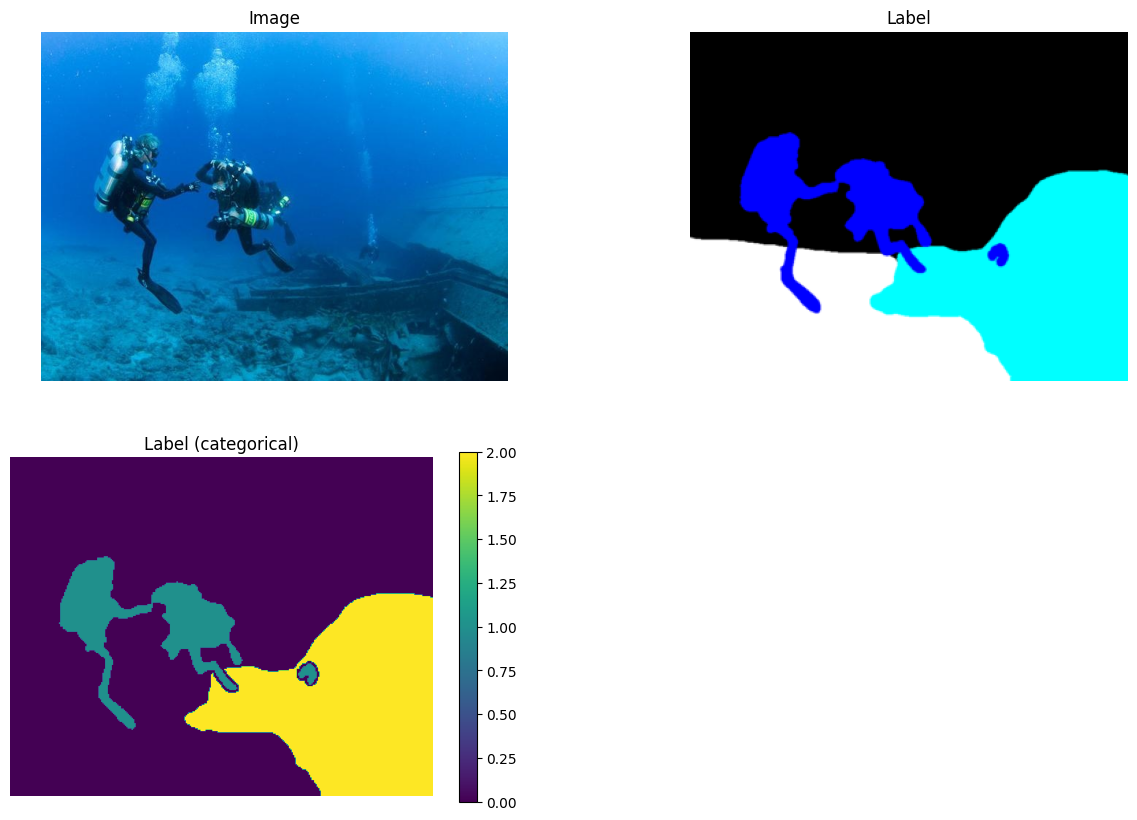

Label masks shape: torch.Size([6, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.int64, min: 0, max: 1
Labels tensor shape: torch.Size([1, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.int64, min: 0, max: 2


In [10]:
transform_images = transforms.Compose([
    transforms.Resize((256, 320)),
    transforms.ToTensor(), # Converts the image to a tensor with values between 0 and 1
])
transform_labels = transforms.Compose([
    transforms.Resize((256, 320)),
])

dataset = SuimDataset(
    [(
        os.path.join(dir__dataset_trainvalidation_images, "d_r_103_.jpg"),
        os.path.join(dir__dataset_trainvalidation_labels, "d_r_103_.bmp"),
    )],
    color_mapping = colors_to_5cats,
    transform_images = transform_images,
    transform_labels = transform_labels,
    verbose = True,
)
assert len(dataset) == 1
image, label_masks, labels_tensor = dataset[0]

assert image.shape == (3, 256, 320)
assert image.min() >= 0
assert image.max() <= 1

# image contains 3 classes (0, 1, 2)
assert label_masks.shape == (6, 256, 320)
assert label_masks.min() == 0
assert label_masks.max() == 1
assert label_masks[0].min() == 0
assert label_masks[0].max() == 1
assert label_masks[1].min() == 0
assert label_masks[1].max() == 1
assert label_masks[2].min() == 0
assert label_masks[2].max() == 1
# classes 3, 4, 5 are not present in the label
assert label_masks[3].min() == 0
assert label_masks[3].max() == 0
assert label_masks[4].min() == 0
assert label_masks[4].max() == 0
assert label_masks[5].min() == 0
assert label_masks[5].max() == 0

# image contains 3 classes (0, 1, 2)
assert labels_tensor.shape == (1, 256, 320)
assert labels_tensor.min() == 0
assert labels_tensor.max() == 2

# Models

In [11]:
class Classifier(pl.LightningModule):
    def __init__(self,
                 model,
                 num_classes,
                 lr = 1e-4):
        super().__init__()
        self.model = model
        self.lr = lr
        self.criterion = nn.CrossEntropyLoss()

        self.train_accuracy_f1score = torchmetrics.F1Score(task = "multiclass", num_classes = num_classes)
        self.train_accuracy_mIoU = torchmetrics.JaccardIndex(task = "multiclass", num_classes = num_classes)
        self.train_loss = torchmetrics.MeanMetric()

        self.val_accuracy_f1score = torchmetrics.F1Score(task = "multiclass", num_classes = num_classes)
        self.val_accuracy_mIoU = torchmetrics.JaccardIndex(task = "multiclass", num_classes = num_classes)
        self.val_loss = torchmetrics.MeanMetric()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, _, labels = batch
        labels = labels.squeeze(1)

        outputs = self(images)
        loss = self.criterion(outputs, labels)
        preds = torch.argmax(outputs, dim = 1)

        self.train_accuracy_f1score(preds, labels)
        self.train_accuracy_mIoU(preds, labels)
        self.train_loss(loss)

        self.log("train/acc_f1score_step", self.train_accuracy_f1score, prog_bar = True)
        self.log("train/acc_mIoU_step", self.train_accuracy_mIoU, prog_bar = True)
        self.log("train/loss_step", self.train_loss, prog_bar = True)

        return loss

    def on_train_epoch_end(self):
        self.log("train/acc_f1score_epoch", self.train_accuracy_f1score)
        self.log("train/acc_mIoU_epoch", self.train_accuracy_mIoU)
        self.log("train/loss_epoch", self.train_loss)

    def validation_step(self, batch, batch_idx):
        images, _, labels = batch
        labels = labels.squeeze(1)

        outputs = self(images)
        loss = self.criterion(outputs, labels)
        preds = torch.argmax(outputs, dim = 1)

        self.val_accuracy_f1score(preds, labels)
        self.val_accuracy_mIoU(preds, labels)
        self.val_loss(loss)

        self.log("val/acc_f1score_step", self.val_accuracy_f1score, prog_bar = True)
        self.log("val/acc_mIoU_step", self.val_accuracy_mIoU, prog_bar = True)
        self.log("val/loss_step", self.val_loss, prog_bar = True)

        return loss

    def on_validation_epoch_end(self):
        self.log("val/acc_f1score_epoch", self.val_accuracy_f1score)
        self.log("val/acc_mIoU_epoch", self.val_accuracy_mIoU)
        self.log("val/loss_epoch", self.val_loss)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr = self.lr)

## SuimNET VVG

In [12]:
class UpSampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UpSampleBlock, self).__init__()
        self.upsample = nn.Upsample(scale_factor = 2, mode = 'bilinear', align_corners = False)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size = 3, padding = 1, stride = 1)
        self.relu = nn.ReLU(inplace = True)
        self.bn = nn.BatchNorm2d(out_channels, momentum = 0.8)

    def forward(self, x, skip):
        x = self.upsample(x)
        x = self.conv(x)
        x = self.relu(x)
        x = self.bn(x)
        x = torch.cat([x, skip], dim = 1)
        return x


class SUIMNetVGG16(nn.Module):
    def __init__(self, num_classes = 8):
        super(SUIMNetVGG16, self).__init__()
        vgg = models.vgg16(weights = VGG16_Weights.IMAGENET1K_V1)
        self.encoder1 = nn.Sequential(*vgg.features[:5])     # Block 1
        self.encoder2 = nn.Sequential(*vgg.features[5:10])   # Block 2
        self.encoder3 = nn.Sequential(*vgg.features[10:17])  # Block 3
        self.encoder4 = nn.Sequential(*vgg.features[17:24])  # Block 4

        self.decoder1 = UpSampleBlock(512,       768)
        self.decoder2 = UpSampleBlock(768 + 256, 384)
        self.decoder3 = UpSampleBlock(384 + 128, 192)
        self.final_deconv = nn.ConvTranspose2d(256, 192, kernel_size = 2, stride = 2)
        self.output = nn.Conv2d(192, num_classes, kernel_size = 3, padding = 1)

    def forward(self, x):
        # Encoder
        e1 = self.encoder1(x)
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)

        # Decoder
        d1 = self.decoder1(e4, e3)
        d2 = self.decoder2(d1, e2)
        d3 = self.decoder3(d2, e1)
        d4 = self.final_deconv(d3)
        out = self.output(d4)
        return torch.sigmoid(out)

### Tests

In [13]:
model = SUIMNetVGG16(num_classes = 8)
input_tensor = torch.randn(1, 3, 320, 256)  # Batch size 1, RGB, 320x256
output = model(input_tensor)
assert output.shape == (1, 8, 320, 256)

### Run

In [15]:
transform_images = transforms.Compose([
    transforms.Resize((256, 320)),
    transforms.ToTensor(), # Converts the image to a tensor with values between 0 and 1
])
transform_labels = transforms.Compose([
    transforms.Resize((256, 320)),
])

batch_size = 8
num_workers = 2

trainvalidation_dataset = SuimDataset(trainvalidation_tuples_paths, colors_to_5cats, transform_images, transform_labels)
trainvalidation_dataloader = DataLoader(trainvalidation_dataset, batch_size = batch_size, shuffle = True) #, num_workers = num_workers) #, persistent_workers = True, pin_memory = True)

test_dataset = SuimDataset(test_tuples_paths, colors_to_5cats, transform_images, transform_labels)
test_dataloader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False) #, num_workers = num_workers) #, persistent_workers = True, pin_memory = True)


model = SUIMNetVGG16(num_classes = 6)
classifier = Classifier(model = model, num_classes = 6, lr = 1e-4)

checkpoint_callback = ModelCheckpoint(
    mode = "min",
    save_weights_only = True,
    save_top_k = 1,
    filename = "SUIMNetVGG16_best-model_{epoch:02d}-{train_loss:.4f}",
    verbose = True
)

trainer = pl.Trainer(
    max_epochs = 50,
    callbacks = [checkpoint_callback],
    accelerator = "gpu",
    devices = 1 if torch.cuda.is_available() else None,
    log_every_n_steps = 10
)

trainer.fit(classifier, trainvalidation_dataloader, test_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                   | Type                   | Params | Mode 
--------------------------------------------------------------------------
0 | model                  | SUIMNetVGG16           | 15.8 M | train
1 | criterion              | CrossEntropyLoss       | 0      | train
2 | train_accuracy_f1score | MulticlassF1Score      | 0      | train
3 | train_accuracy_mIoU    | MulticlassJaccardIndex | 0      | train
4 | train_loss             | MeanMetric             | 0      | train
5 | val_accuracy_f1score   | MulticlassF1Score      | 0      | train
6 | val_accuracy_mIoU      | MulticlassJaccardIndex | 0      | tra

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

RuntimeError: CUDA error: unknown error
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
